In [14]:
import pandas as pd
import os 
from scipy.stats import ttest_rel, wilcoxon
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
csv_file = "iterative_improvement_results.csv"
df = pd.read_csv(csv_file)

# Expected columns:
# instance, pivoting_rule, neighborhood, initial_solution, cost, delta_percent, time_seconds

In [ ]:
# ------------------------------------------------------------
# Table 1: Main results for the 12 iterative improvement algorithms
# ------------------------------------------------------------
table1 = (
    df.groupby(["pivoting_rule", "neighborhood", "initial_solution"], as_index=False)
      .agg(
          avg_deviation_percent=("delta_percent", "mean"),
          std_deviation_percent=("delta_percent", "std"),
          total_time_seconds=("time_seconds", "sum"),
          avg_time_per_instance_seconds=("time_seconds", "mean")
      )
)

table1 = table1.sort_values(
    by=["avg_deviation_percent", "total_time_seconds"],
    ascending=[True, True]
).reset_index(drop=True)

print("\n=== TABLE 1: Main results for the 12 algorithms ===")
# print(table1.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
# table1.to_csv("table1_main_results.csv", index=False, sep=",")
table1


=== TABLE 1: Main results for the 12 algorithms ===


,pivoting_rule,neighborhood,initial_solution,avg_deviation_percent,std_deviation_percent,total_time_seconds,avg_time_per_instance_seconds
0,first,insert,cw,2.016442,0.410891,125.954386,1.614800
1,first,insert,random,2.068041,0.439775,189.393268,2.428119
2,best,insert,cw,2.260752,0.406487,34.537071,0.442783
3,best,insert,random,2.298090,0.440316,38.955614,0.499431
4,first,exchange,random,2.859017,0.493355,217.268761,2.785497
5,first,exchange,cw,2.965992,0.461317,173.139520,2.219737
6,best,exchange,random,3.635922,0.603032,33.634012,0.431205
7,best,exchange,cw,3.846479,0.605363,31.296686,0.401240
8,best,transpose,cw,17.078297,1.606525,0.219092,0.002809
9,first,transpose,cw,17.086306,1.604160,0.268443,0.003442


In [ ]:
# ------------------------------------------------------------
# Table 2: Best algorithms by quality and by speed
# ------------------------------------------------------------
best_quality = table1.loc[table1["avg_deviation_percent"].idxmin()]
second_best_quality = table1.nsmallest(2, "avg_deviation_percent").iloc[1]
fastest = table1.loc[table1["total_time_seconds"].idxmin()]
slowest = table1.loc[table1["total_time_seconds"].idxmax()]

cw_only = table1[table1["initial_solution"] == "cw"]
fastest_cw = cw_only.loc[cw_only["total_time_seconds"].idxmin()]

table2 = pd.DataFrame([
    {
        "criterion": "Best average deviation",
        "pivoting_rule": best_quality["pivoting_rule"],
        "neighborhood": best_quality["neighborhood"],
        "initial_solution": best_quality["initial_solution"],
# print(table4.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
        "value": best_quality["avg_deviation_percent"]
    },
    {
        "criterion": "Second best average deviation",
        "pivoting_rule": second_best_quality["pivoting_rule"],
        "neighborhood": second_best_quality["neighborhood"],
        "initial_solution": second_best_quality["initial_solution"],
        "value": second_best_quality["avg_deviation_percent"]
    },
    {
        "criterion": "Fastest total time",
        "pivoting_rule": fastest["pivoting_rule"],
        "neighborhood": fastest["neighborhood"],
        "initial_solution": fastest["initial_solution"],
        "value": fastest["total_time_seconds"]
    },
    {
        "criterion": "Fastest CW-based algorithm",
        "pivoting_rule": fastest_cw["pivoting_rule"],
        "neighborhood": fastest_cw["neighborhood"],
        "initial_solution": fastest_cw["initial_solution"],
        "value": fastest_cw["total_time_seconds"]
    },
    {
        "criterion": "Slowest algorithm",
        "pivoting_rule": slowest["pivoting_rule"],
        "neighborhood": slowest["neighborhood"],
        "initial_solution": slowest["initial_solution"],
        "value": slowest["total_time_seconds"]
    }
])

print("\n=== TABLE 2: Best/worst algorithms ===")
# print(table2.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
# table2.to_csv("table2_best_worst_algorithms.csv", index=False, sep=",")
table2 


=== TABLE 2: Best/worst algorithms ===


,criterion,pivoting_rule,neighborhood,initial_solution,value
0,Best average deviation,first,insert,cw,2.016442
1,Second best average deviation,first,insert,random,2.068041
2,Fastest total time,best,transpose,random,0.003070
3,Fastest CW-based algorithm,best,transpose,cw,0.219092
4,Slowest algorithm,first,exchange,random,217.268761


In [ ]:
# ------------------------------------------------------------
# Table 3: Effect of the initial solution
# ------------------------------------------------------------

table3 = (
    table1.groupby("initial_solution", as_index=False)
          .agg(mean_of_avg_deviations=("avg_deviation_percent", "mean"))
)

print("\n=== TABLE 3: Effect of the initial solution ===")
# print(table3.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
table3
if set(table3["initial_solution"]) == {"cw", "random"}:
    cw_mean = table3.loc[table3["initial_solution"] == "cw", "mean_of_avg_deviations"].iloc[0]
    rand_mean = table3.loc[table3["initial_solution"] == "random", "mean_of_avg_deviations"].iloc[0]
    print(f"\nCW reduces the mean deviation by {rand_mean - cw_mean:.6f} percentage points.")
    
# table3.to_csv("table3_initial_solution_effect.csv", index=False, sep=",")
table3



=== TABLE 3: Effect of the initial solution ===

CW reduces the mean deviation by 5.693287 percentage points.


,initial_solution,mean_of_avg_deviations
0,cw,7.542378
1,random,13.235665


In [ ]:
# ------------------------------------------------------------
# Table 4: Effect of pivoting rule within same initialization and neighborhood
# ------------------------------------------------------------
table4 = (
    table1.pivot_table(
        index=["initial_solution", "neighborhood"],
        columns="pivoting_rule",
        values="avg_deviation_percent"
    )
    .reset_index()
)

table4.columns.name = None

# optional: reorder columns if both exist
wanted = ["initial_solution", "neighborhood", "first", "best"]
table4 = table4[[c for c in wanted if c in table4.columns]]

if {"first", "best"}.issubset(table4.columns):
    table4["better_one"] = table4.apply(
        lambda row: "best" if row["best"] < row["first"]
        else ("first" if row["first"] < row["best"] else "tie"),
        axis=1
    )

# table4.to_csv("table4_pivoting_comparison.csv", index=False, sep=",")
table4

,initial_solution,neighborhood,first,best,better_one
0,cw,exchange,2.965992,3.846479,first
1,cw,insert,2.016442,2.260752,first
2,cw,transpose,17.086306,17.078297,best
3,random,exchange,2.859017,3.635922,first
4,random,insert,2.068041,2.298090,first
5,random,transpose,34.456315,34.096605,best


In [ ]:
# ------------------------------------------------------------
# Table 5: Effect of neighborhood within same pivoting rule and initialization
# ------------------------------------------------------------
table5 = (
    table1.pivot_table(
        index=["pivoting_rule", "initial_solution"],
        columns="neighborhood",
        values="avg_deviation_percent"
    )
    .reset_index()
)

table5.columns.name = None

wanted = ["pivoting_rule", "initial_solution", "transpose", "exchange", "insert"]
table5 = table5[[c for c in wanted if c in table5.columns]]

def best_neighborhood(row):
    candidates = {
        n: row[n]
        for n in ["transpose", "exchange", "insert"]
        if n in table5.columns and pd.notna(row[n])
    }
    if not candidates:
        return None
    best_val = min(candidates.values())
    best_names = [k for k, v in candidates.items() if v == best_val]
    return " / ".join(best_names)

table5["best_neighborhood"] = table5.apply(best_neighborhood, axis=1)

# table5.to_csv("table5_neighborhood_comparison.csv", index=False, sep=",")
table5


,pivoting_rule,initial_solution,transpose,exchange,insert,best_neighborhood
0,best,cw,17.078297,3.846479,2.260752,insert
1,best,random,34.096605,3.635922,2.298090,insert
2,first,cw,17.086306,2.965992,2.016442,insert
3,first,random,34.456315,2.859017,2.068041,insert


In [ ]:
# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
INPUT_CSV = "iterative_improvement_results.csv"
OUTPUT_CSV = "pairwise_algorithm_comparisons.csv"
ALPHA = 0.05

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

# Expected columns:
# instance, pivoting_rule, neighborhood, initial_solution, cost, delta_percent, time_seconds

required_cols = {
    "instance",
    "pivoting_rule",
    "neighborhood",
    "initial_solution",
    "delta_percent"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# Build algorithm label
# ------------------------------------------------------------
df["algorithm"] = (
    df["pivoting_rule"].astype(str) + "_" +
    df["neighborhood"].astype(str) + "_" +
    df["initial_solution"].astype(str)
)

# ------------------------------------------------------------
# Get all algorithms
# ------------------------------------------------------------
algorithms = sorted(df["algorithm"].unique())
# print(f"Found {len(algorithms)} algorithms:")
# for a in algorithms:
#     print(" -", a)

# ------------------------------------------------------------
# Pairwise comparison function
# ------------------------------------------------------------
def compare_two_algorithms(df_all, alg1, alg2):
    df1 = df_all[df_all["algorithm"] == alg1][["instance", "delta_percent"]].copy()
    df2 = df_all[df_all["algorithm"] == alg2][["instance", "delta_percent"]].copy()

    df1 = df1.rename(columns={"delta_percent": "delta_1"})
    df2 = df2.rename(columns={"delta_percent": "delta_2"})

    merged = pd.merge(df1, df2, on="instance", how="inner").sort_values("instance")

    if merged.empty:
        raise ValueError(f"No common instances between {alg1} and {alg2}")

    x = merged["delta_1"].to_numpy()
    y = merged["delta_2"].to_numpy()

    # Mean values
    mean_1 = x.mean()
    mean_2 = y.mean()
    mean_diff = (x - y).mean()   # positive => alg1 worse if lower delta is better
    abs_mean_diff = abs(mean_diff)

    # Lower delta_percent is better
    if mean_1 < mean_2:
        better_mean = alg1
    elif mean_2 < mean_1:
        better_mean = alg2
    else:
        better_mean = "tie"

    # Paired t-test
    t_stat, p_ttest = ttest_rel(x, y, nan_policy="omit")

    # Wilcoxon signed-rank test
    # If all differences are exactly zero, wilcoxon fails
    diffs = x - y
    if (diffs == 0).all():
        w_stat = 0.0
        p_wilcoxon = 1.0
    else:
        try:
            w_stat, p_wilcoxon = wilcoxon(x, y, zero_method="wilcox")
        except ValueError:
            # fallback in edge cases
            w_stat, p_wilcoxon = float("nan"), float("nan")

    return {
        "algorithm_1": alg1,
        "algorithm_2": alg2,
        "n_instances": len(merged),
        "mean_delta_1": mean_1,
        "mean_delta_2": mean_2,
        "mean_diff_delta_1_minus_2": mean_diff,
        "abs_mean_diff": abs_mean_diff,
        "better_by_mean": better_mean,
        "t_statistic": t_stat,
        "p_value_ttest": p_ttest,
        "significant_ttest": p_ttest < ALPHA if pd.notna(p_ttest) else False,
        "wilcoxon_statistic": w_stat,
        "p_value_wilcoxon": p_wilcoxon,
        "significant_wilcoxon": p_wilcoxon < ALPHA if pd.notna(p_wilcoxon) else False,
    }

# ------------------------------------------------------------
# Compare all pairs
# ------------------------------------------------------------
results = []

for alg1, alg2 in combinations(algorithms, 2):
    res = compare_two_algorithms(df, alg1, alg2)
    results.append(res)

results_df = pd.DataFrame(results)

# Sort: strongest Wilcoxon significance first, then t-test
results_df = results_df.sort_values(
    by=["p_value_wilcoxon", "p_value_ttest", "abs_mean_diff"],
    ascending=[True, True, False]
).reset_index(drop=True)

# results_df.to_csv("results_algo_comparison.csv", index=False, sep=",")
results_df

,algorithm_1,algorithm_2,n_instances,mean_delta_1,mean_delta_2,mean_diff_delta_1_minus_2,abs_mean_diff,better_by_mean,t_statistic,p_value_ttest,significant_ttest,wilcoxon_statistic,p_value_wilcoxon,significant_wilcoxon
0,first_insert_random,first_transpose_cw,78,2.068041,17.086306,-15.018265,15.018265,first_insert_random,-86.766304,1.466055e-78,True,0.0,1.682175e-14,True
1,best_transpose_cw,first_insert_random,78,17.078297,2.068041,15.010255,15.010255,first_insert_random,86.640800,1.637085e-78,True,0.0,1.682175e-14,True
2,best_insert_random,best_transpose_random,78,2.298090,34.096605,-31.798515,31.798515,best_insert_random,-85.454972,4.679956e-78,True,0.0,1.682175e-14,True
3,best_transpose_random,first_insert_random,78,34.096605,2.068041,32.028564,32.028564,first_insert_random,85.157139,6.106439e-78,True,0.0,1.682175e-14,True
4,best_insert_cw,best_transpose_random,78,2.260752,34.096605,-31.835853,31.835853,best_insert_cw,-84.252603,1.377684e-77,True,0.0,1.682175e-14,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,best_transpose_cw,first_transpose_cw,78,17.078297,17.086306,-0.008010,0.008010,best_transpose_cw,-2.137571,3.572496e-02,True,1142.0,9.652677e-02,False
62,first_exchange_cw,first_exchange_random,78,2.965992,2.859017,0.106974,0.106974,first_exchange_random,1.808386,7.445074e-02,False,1220.0,1.104149e-01,False
63,first_insert_cw,first_insert_random,78,2.016442,2.068041,-0.051600,0.051600,first_insert_cw,-0.923404,3.586811e-01,False,1327.0,2.876048e-01,False
64,best_transpose_random,first_transpose_random,78,34.096605,34.456315,-0.359710,0.359710,best_transpose_random,-0.905049,3.682626e-01,False,1419.0,5.450718e-01,False


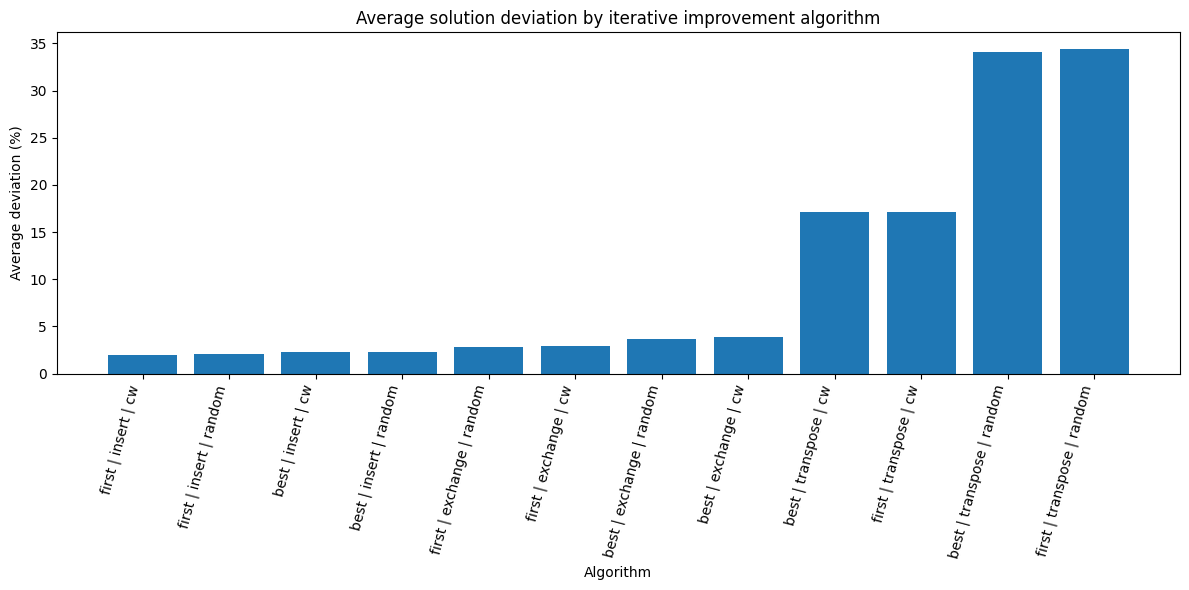

In [ ]:
# Bar chart of average deviation by algorithm

table1_plot = table1.copy()
table1_plot["algorithm"] = (
    table1_plot["pivoting_rule"] + " | "
    + table1_plot["neighborhood"] + " | "
    + table1_plot["initial_solution"]
)

table1_plot = table1_plot.sort_values("avg_deviation_percent")

plt.figure(figsize=(12, 6))
plt.bar(table1_plot["algorithm"], table1_plot["avg_deviation_percent"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Average deviation (%)")
plt.xlabel("Algorithm")
plt.title("Average solution deviation by iterative improvement algorithm")
plt.tight_layout()
plt.show()

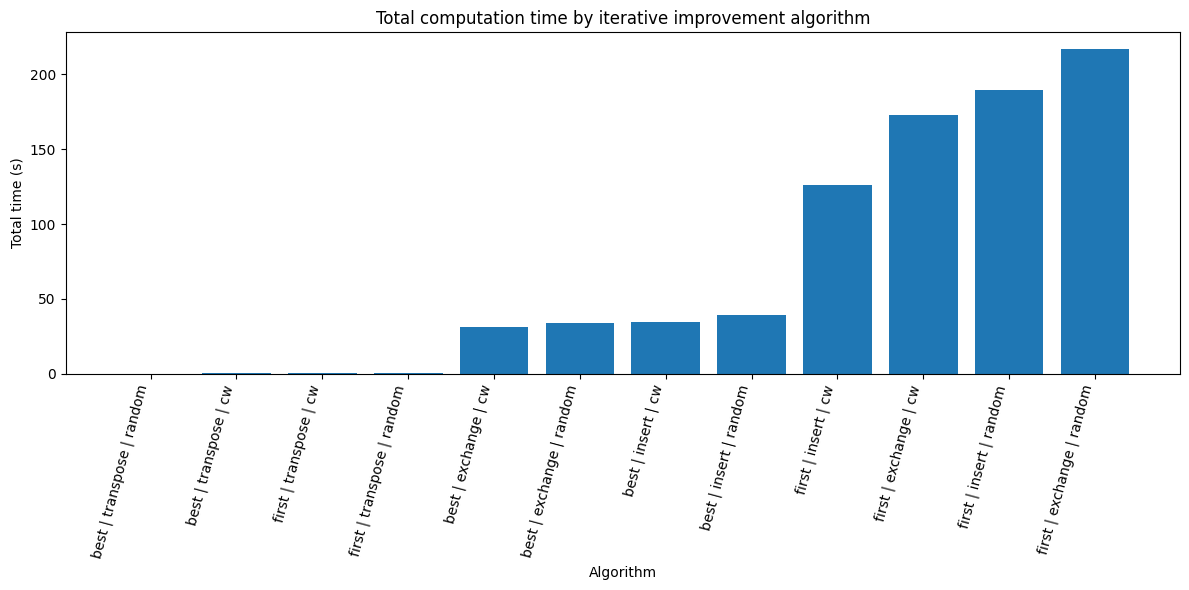

In [ ]:
# Bar chart of total time by algorithm

table1_plot = table1.copy()
table1_plot["algorithm"] = (
    table1_plot["pivoting_rule"] + " | "
    + table1_plot["neighborhood"] + " | "
    + table1_plot["initial_solution"]
)

table1_plot = table1_plot.sort_values("total_time_seconds")

plt.figure(figsize=(12, 6))
plt.bar(table1_plot["algorithm"], table1_plot["total_time_seconds"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Total time (s)")
plt.xlabel("Algorithm")
plt.title("Total computation time by iterative improvement algorithm")
plt.tight_layout()
plt.show()

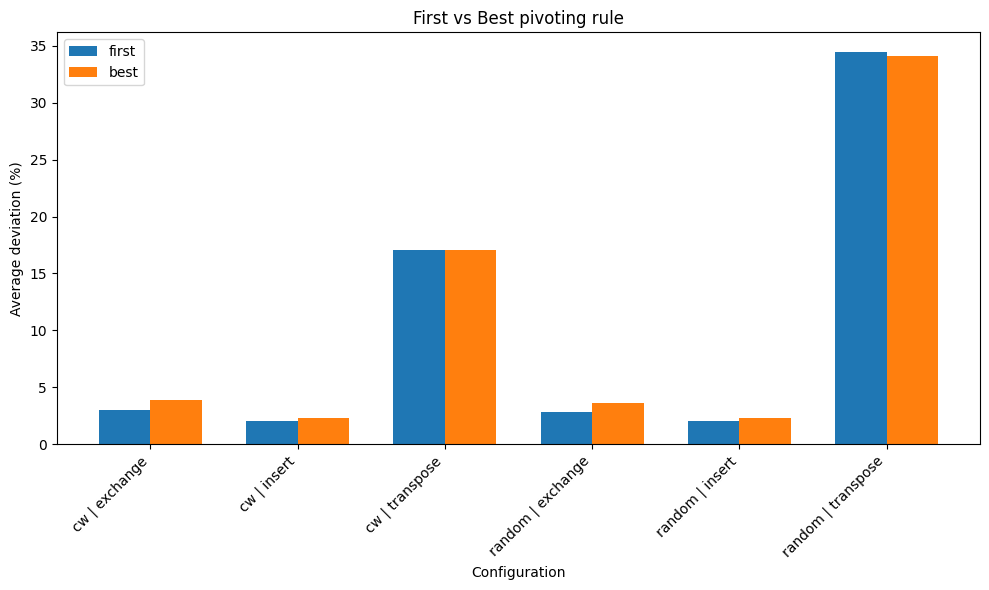

In [ ]:
# Grouped bar chart: First vs Best inside each neighborhood and initialization

plot_df = table4.copy()
plot_df["config"] = plot_df["initial_solution"] + " | " + plot_df["neighborhood"]

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df["first"], width, label="first")
plt.bar(x + width/2, plot_df["best"], width, label="best")

plt.xticks(x, plot_df["config"], rotation=45, ha="right")
plt.ylabel("Average deviation (%)")
plt.xlabel("Configuration")
plt.title("First vs Best pivoting rule")
plt.legend()
plt.tight_layout()
plt.show()

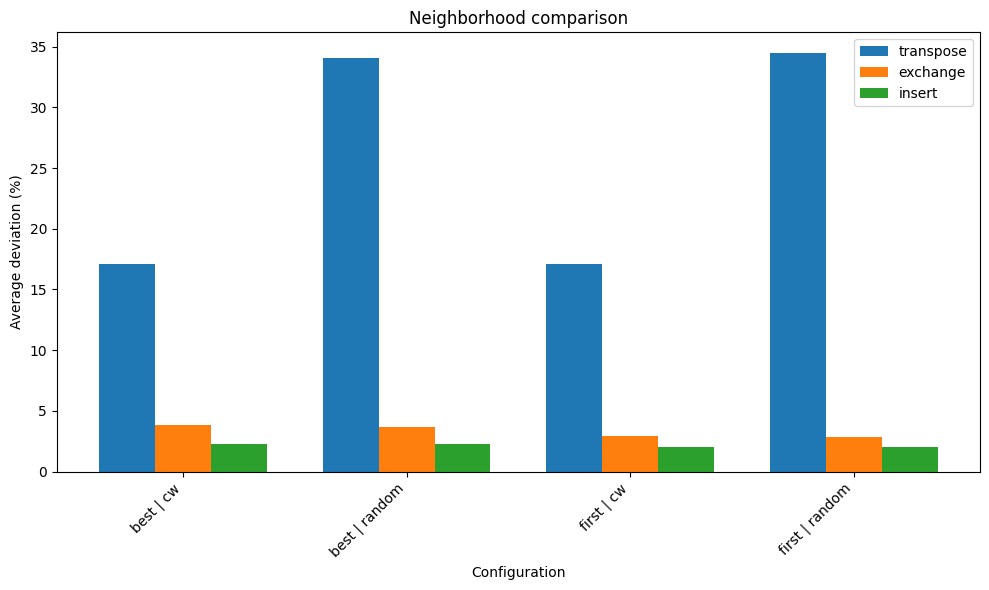

In [ ]:

# Grouped bar chart: neighborhood comparison
plot_df = table5.copy()
plot_df["config"] = plot_df["pivoting_rule"] + " | " + plot_df["initial_solution"]

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, plot_df["transpose"], width, label="transpose")
plt.bar(x,         plot_df["exchange"],  width, label="exchange")
plt.bar(x + width, plot_df["insert"],    width, label="insert")

plt.xticks(x, plot_df["config"], rotation=45, ha="right")
plt.ylabel("Average deviation (%)")
plt.xlabel("Configuration")
plt.title("Neighborhood comparison")
plt.legend()
plt.tight_layout()
plt.show()

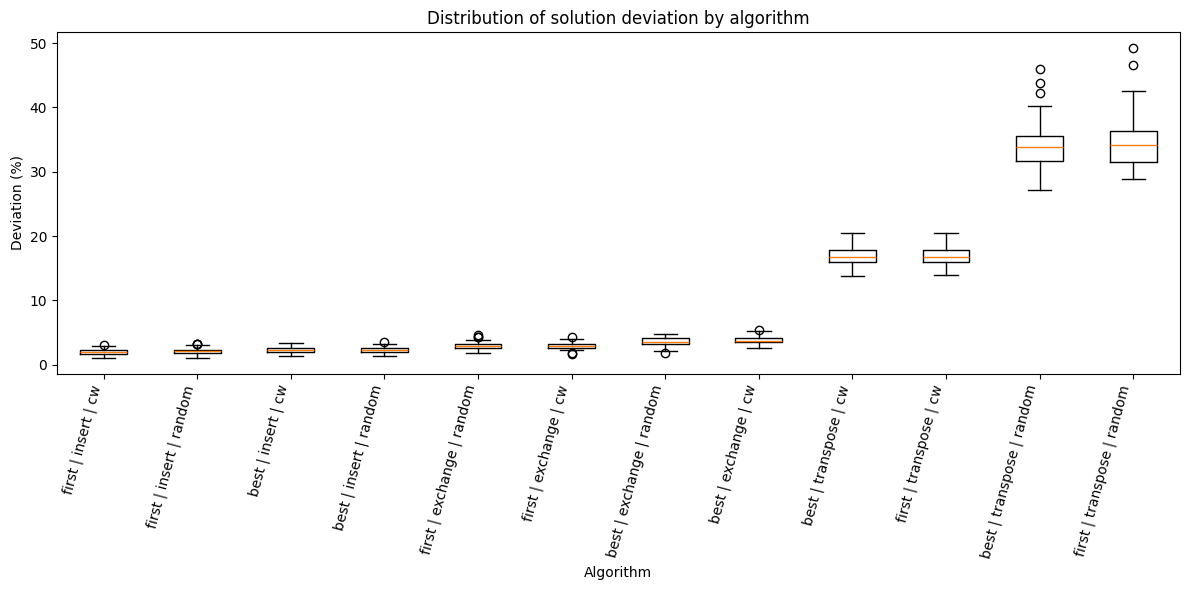

In [21]:
# Boxplot of per-instance deviations by algorithm

iter_df_plot = df.copy()
iter_df_plot["algorithm"] = (
    iter_df_plot["pivoting_rule"] + " | "
    + iter_df_plot["neighborhood"] + " | "
    + iter_df_plot["initial_solution"]
)

order = (
    iter_df_plot.groupby("algorithm")["delta_percent"]
    .mean()
    .sort_values()
    .index
)

data = [iter_df_plot.loc[iter_df_plot["algorithm"] == alg, "delta_percent"] for alg in order]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=order)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Deviation (%)")
plt.xlabel("Algorithm")
plt.title("Distribution of solution deviation by algorithm")
plt.tight_layout()
plt.show()